In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [5]:
data = pd.read_csv("C:\\Users\\srush\\OneDrive\\Desktop\\AIML Internship\\AIML-Internship\\Day 14\\car_price_prediction.csv")
data

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19232,45798355,8467,-,MERCEDES-BENZ,CLK 200,1999,Coupe,Yes,CNG,2.0 Turbo,300000 km,4.0,Manual,Rear,02-Mar,Left wheel,Silver,5
19233,45778856,15681,831,HYUNDAI,Sonata,2011,Sedan,Yes,Petrol,2.4,161600 km,4.0,Tiptronic,Front,04-May,Left wheel,Red,8
19234,45804997,26108,836,HYUNDAI,Tucson,2010,Jeep,Yes,Diesel,2,116365 km,4.0,Automatic,Front,04-May,Left wheel,Grey,4
19235,45793526,5331,1288,CHEVROLET,Captiva,2007,Jeep,Yes,Diesel,2,51258 km,4.0,Automatic,Front,04-May,Left wheel,Black,4


In [7]:
data.size

346266

In [8]:
data.shape

(19237, 18)

In [9]:
data.info

<bound method DataFrame.info of              ID  Price  Levy   Manufacturer    Model  Prod. year   Category  \
0      45654403  13328  1399          LEXUS   RX 450        2010       Jeep   
1      44731507  16621  1018      CHEVROLET  Equinox        2011       Jeep   
2      45774419   8467     -          HONDA      FIT        2006  Hatchback   
3      45769185   3607   862           FORD   Escape        2011       Jeep   
4      45809263  11726   446          HONDA      FIT        2014  Hatchback   
...         ...    ...   ...            ...      ...         ...        ...   
19232  45798355   8467     -  MERCEDES-BENZ  CLK 200        1999      Coupe   
19233  45778856  15681   831        HYUNDAI   Sonata        2011      Sedan   
19234  45804997  26108   836        HYUNDAI   Tucson        2010       Jeep   
19235  45793526   5331  1288      CHEVROLET  Captiva        2007       Jeep   
19236  45813273    470   753        HYUNDAI   Sonata        2012      Sedan   

      Leather inter

In [10]:
data.describe()

,ID,Price,Prod. year,Cylinders,Airbags
count,1.923700e+04,1.923700e+04,19237.000000,19237.000000,19237.000000
mean,4.557654e+07,1.855593e+04,2010.912824,4.582991,6.582627
std,9.365914e+05,1.905813e+05,5.668673,1.199933,4.320168
min,2.074688e+07,1.000000e+00,1939.000000,1.000000,0.000000
25%,4.569837e+07,5.331000e+03,2009.000000,4.000000,4.000000
50%,4.577231e+07,1.317200e+04,2012.000000,4.000000,6.000000
75%,4.580204e+07,2.207500e+04,2015.000000,4.000000,12.000000
max,4.581665e+07,2.630750e+07,2020.000000,16.000000,16.000000


In [11]:
## Checking for null values
data.isnull().sum()

ID                  0
Price               0
Levy                0
Manufacturer        0
Model               0
Prod. year          0
Category            0
Leather interior    0
Fuel type           0
Engine volume       0
Mileage             0
Cylinders           0
Gear box type       0
Drive wheels        0
Doors               0
Wheel               0
Color               0
Airbags             0
dtype: int64

In [12]:
## Checking duplicate values
data.duplicated().sum()

np.int64(313)

In [13]:
## Removing duplicates
data = data.drop_duplicates()

In [14]:
## After removing duplicates
data.duplicated().sum()

np.int64(0)

In [15]:
# Checking the data shape after removing duplicates
data.shape

(18924, 18)

In [16]:
## Checking the Categorical columns
data.select_dtypes(include=['object']).columns

C:\Users\srush\AppData\Local\Temp\ipykernel_34396\349007237.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  data.select_dtypes(include=['object']).columns


Index(['Levy', 'Manufacturer', 'Model', 'Category', 'Leather interior',
       'Fuel type', 'Engine volume', 'Mileage', 'Gear box type',
       'Drive wheels', 'Doors', 'Wheel', 'Color'],
      dtype='str')

In [17]:
## Converting categorical columns to numeric using one-hot encoding
data = pd.get_dummies(data, drop_first=True)
data

,ID,Price,Prod. year,Cylinders,Airbags,Levy_1011,Levy_1016,Levy_1017,Levy_1018,Levy_1024,...,Color_Green,Color_Grey,Color_Orange,Color_Pink,Color_Purple,Color_Red,Color_Silver,Color_Sky blue,Color_White,Color_Yellow
0,45654403,13328,2010,6.0,12,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
1,44731507,16621,2011,6.0,8,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
2,45774419,8467,2006,4.0,2,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,45769185,3607,2011,4.0,0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,45809263,11726,2014,4.0,4,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19232,45798355,8467,1999,4.0,5,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
19233,45778856,15681,2011,4.0,8,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
19234,45804997,26108,2010,4.0,4,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
19235,45793526,5331,2007,4.0,4,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [18]:
##### Data Distribution #####
data.describe()

,ID,Price,Prod. year,Cylinders,Airbags
count,1.892400e+04,1.892400e+04,18924.000000,18924.000000,18924.000000
mean,4.557538e+07,1.858744e+04,2010.914236,4.580216,6.568379
std,9.375468e+05,1.921356e+05,5.665749,1.200223,4.322323
min,2.074688e+07,1.000000e+00,1939.000000,1.000000,0.000000
25%,4.569501e+07,5.331000e+03,2009.000000,4.000000,4.000000
50%,4.577191e+07,1.317200e+04,2012.000000,4.000000,6.000000
75%,4.580174e+07,2.206300e+04,2015.000000,4.000000,12.000000
max,4.581665e+07,2.630750e+07,2020.000000,16.000000,16.000000


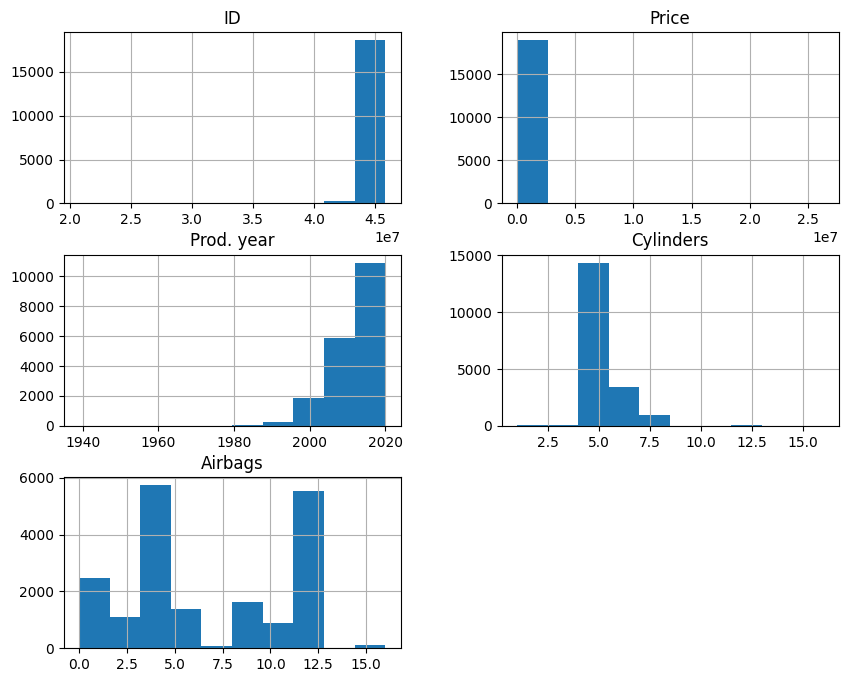

In [21]:
#### Histogram ####
import matplotlib.pyplot as plt
data.hist(figsize=(10, 8))
plt.show()

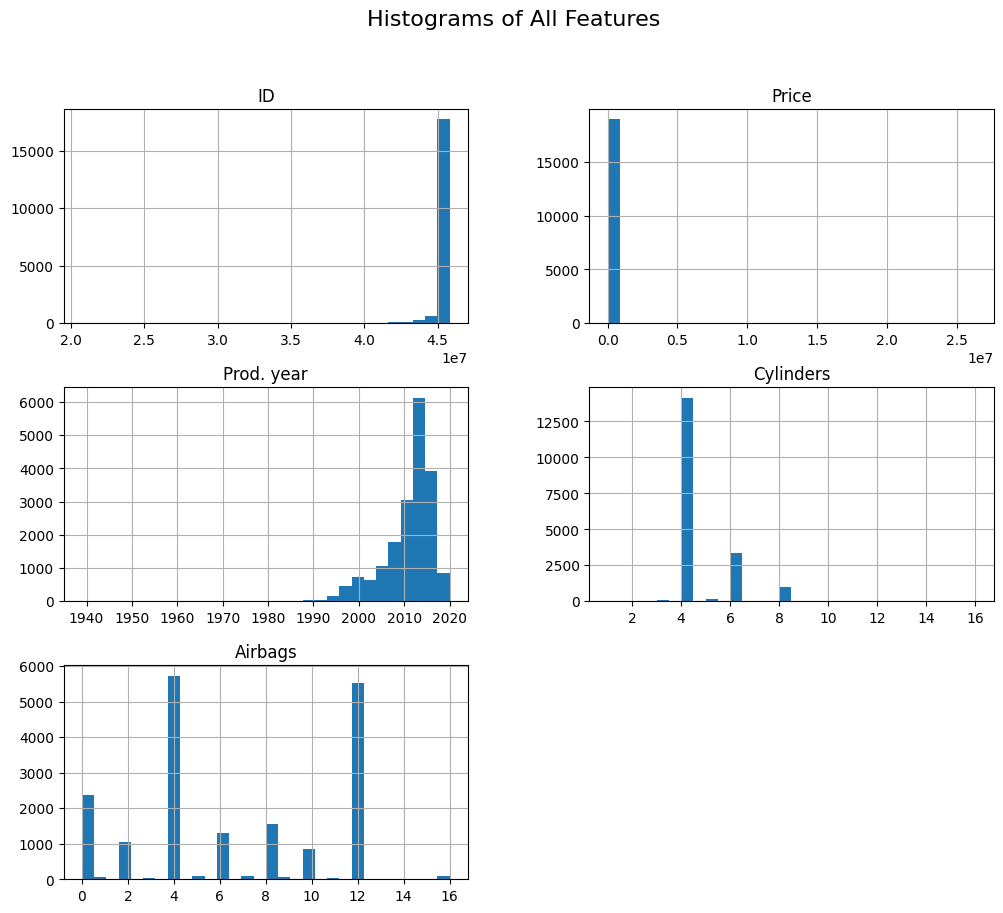

In [22]:
data.hist(bins=30, figsize=(12, 10))    
plt.suptitle('Histograms of All Features', fontsize=16)
plt.show()

In [24]:
## Checking for skewness in the data ##
data.skew()

ID                -11.902636
Price             135.387726
Prod. year         -2.088595
Cylinders           2.107707
Airbags             0.086344
                     ...    
Color_Red           5.240494
Color_Silver        1.523350
Color_Sky blue     12.334722
Color_White         1.264083
Color_Yellow       13.313987
Length: 10048, dtype: float64